In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/finance_assignment


Mounted at /content/drive/
/content/drive/MyDrive/finance_assignment


In [3]:
# import data/stock_data.parquet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, Dense, concatenate, Input
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import pandas as pd

df = pd.read_parquet('data/stock_data.parquet')

We now augment the data so we can attatch sentiments to the historical price of each of the stocks.

In [4]:
sentiment_data = pd.read_csv('data/sentiment_data.csv', converters={'stock_codes': ast.literal_eval})
sentiment_data['datetime'] = pd.to_datetime(sentiment_data['date_string'])
sentiment_data

# give me a function, that given a stock code ticker eg. BHP, it looks at the stock_codes column and looks for all articles that say ASX:that ticker and assembles a new dataframe that has the columns: title, url, datetime, vader_negative	vader_neutral	vader_positive	vader_compound	bert_sentiment_score

  # Search for articles related to the stock ticker
def get_stock_sentiment(stock_ticker, sentiment_data):
  search_term = f'ASX:{stock_ticker.upper()}'  # Create search term
  filtered_data = sentiment_data[sentiment_data['stock_codes'].apply(lambda codes: search_term in codes)]

  # Select desired columns
  relevant_columns = ['datetime', 'vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound', 'bert_sentiment_score']
  stock_sentiment_df = filtered_data[relevant_columns].copy()
  stock_sentiment_df.set_index('datetime', inplace=True)
  return stock_sentiment_df


In [5]:
stocks = df.columns.levels[0]
df[stocks[0]].columns


Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')

https://medium.com/thedeephub/rnns-in-action-predicting-stock-prices-with-recurrent-neural-networks-9155a33c4c3b

In [6]:
#df['BHP.AX', 'Close']['2024-01-02']
def get_raw_stock_data(stock_ticker, df=df):
  """given the format BHP, returns df['BHP.AX']"""
  return df[f'{stock_ticker.upper()}.AX'].copy()

stock_name = 'BGD'
sentiment_df = get_stock_sentiment(stock_name, sentiment_data)
price_df = get_raw_stock_data(stock_name)

merged_df = pd.merge(price_df, sentiment_df, left_index=True, right_index=True, how='left').fillna(0)
merged_df

,Open,High,Low,Close,Volume,vader_negative,vader_neutral,vader_positive,vader_compound,bert_sentiment_score
Date,,,,,,,,,,
2024-01-02,0.270,0.270,0.265,0.270,72884,0.0,0.0,0.0,0.0,0.0
2024-01-03,0.275,0.275,0.265,0.265,223264,0.0,0.0,0.0,0.0,0.0
2024-01-04,0.265,0.270,0.265,0.270,92885,0.0,0.0,0.0,0.0,0.0
2024-01-05,0.265,0.270,0.260,0.260,122115,0.0,0.0,0.0,0.0,0.0
2024-01-08,0.260,0.260,0.260,0.260,2235,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2025-03-24,0.320,0.320,0.310,0.315,190352,0.0,0.0,0.0,0.0,0.0
2025-03-25,0.310,0.315,0.300,0.300,181157,0.0,0.0,0.0,0.0,0.0
2025-03-26,0.320,0.320,0.310,0.320,214599,0.0,0.0,0.0,0.0,0.0


In [22]:
control_columns = ['Close', 'Volume']
vader_columns = ['vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound']
bert_columns = ['bert_sentiment_score']
control_dataset = merged_df[control_columns].copy()
vader_dataset = merged_df[control_columns + vader_columns].copy()
bert_dataset = merged_df[control_columns + bert_columns].copy()

def train_test_split(data_df, train_proportion=0.7):
    # Split data into training and testing sets
    train_size = int(len(data_df) * train_proportion)
    train_data, test_data = data_df[:train_size].copy(), data_df[train_size:].copy()

    # Create a single scaler for all columns (features and target)
    scaler = MinMaxScaler()
    scaler.fit(train_data)  # fit on all columns

    # Transform the data using the same scaler
    train_data_scaled = pd.DataFrame(scaler.transform(train_data),
                                     columns=train_data.columns,
                                     index=train_data.index)
    test_data_scaled = pd.DataFrame(scaler.transform(test_data),
                                    columns=test_data.columns,
                                    index=test_data.index)

    # Create dataset with lookback period
    def create_dataset(dataset, historical_window_size_days=30, forecast_length_days=1):
        X, Y = [], []
        feature_names = dataset.columns  # All scaled feature names
        max_index = len(dataset) - historical_window_size_days - forecast_length_days
        for i in range(max_index):
            # Use .iloc to ensure proper row slicing
            X.append(dataset.iloc[i:i+historical_window_size_days].values)
            # Pick the target value from the 'Close' column at the forecast index
            Y.append(dataset['Close'].iloc[i+historical_window_size_days + forecast_length_days - 1])
        return np.array(X), np.array(Y), feature_names

    historical_window_size_days = 30

    X_train, Y_train, feature_names = create_dataset(train_data_scaled, historical_window_size_days)
    X_test, Y_test, _ = create_dataset(test_data_scaled, historical_window_size_days)

    # Ensure proper shape: [samples, timesteps, features]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

    return X_train, Y_train, X_test, Y_test, scaler, feature_names

# Use the same function for each dataset variant:
X_train_control, Y_train_control, X_test_control, Y_test_control, scaler_control, feature_names_control  = train_test_split(control_dataset)
X_train_vader, Y_train_vader, X_test_vader, Y_test_vader, scaler_vader, feature_names_vader = train_test_split(vader_dataset)
X_train_bert, Y_train_bert, X_test_bert, Y_test_bert, scaler_bert, feature_names_bert = train_test_split(bert_dataset)

In [23]:

#According to Kingma et al., 2014, the method is "computationally efficient, has little memory requirement, invariant to diagonal rescaling of gradients, and is well suited for problems that are large in terms of data/parameters".
tf.compat.v1.enable_eager_execution() # allow tf to use numpy

train_epochs = 20


def create_simplernn_model(input_shape):
    adam_optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    rnn_model = Sequential()
    rnn_model.add(SimpleRNN(units=64, activation='tanh', return_sequences=True, input_shape=input_shape))
    rnn_model.add(SimpleRNN(units=32, activation='tanh'))
    rnn_model.add(Dense(1, activation='tanh'))
    rnn_model.compile(loss='mean_squared_error', optimizer=adam_optimizer)
    return rnn_model

# def create_lstm_model(input_shape):
#     adam_optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
#     lstm_model = Sequential()
#     lstm_model.add(LSTM(units=64, activation="tanh", return_sequences=True, input_shape=input_shape))
#     lstm_model.add(LSTM(units=32, activation="tanh"))
#     lstm_model.add(Dense(1, activation='relu'))
#     lstm_model.compile(loss='mean_squared_error', optimizer=adam_optimizer)
#     return lstm_model

# # Train the model (increase epochs to 100 to match the paper if needed)
# lstm_model = create_lstm_model(input_shape)
# lstm_model.fit(X_train, Y_train, epochs=train_epochs, batch_size=64, verbose=1)
input_shape_control = (X_train_control.shape[1], X_train_control.shape[2])
input_shape_vader = (X_train_vader.shape[1], X_train_vader.shape[2])
input_shape_bert = (X_train_bert.shape[1], X_train_bert.shape[2])
control_model = create_simplernn_model(input_shape_control)
control_history = control_model.fit(X_train_control, Y_train_control, epochs=train_epochs, batch_size=64, verbose=1)

vader_model = create_simplernn_model(input_shape_vader)
vader_history = vader_model.fit(X_train_vader, Y_train_vader, epochs=train_epochs, batch_size=64, verbose=1)

bert_model = create_simplernn_model(input_shape_bert)
bert_history = bert_model.fit(X_train_bert, Y_train_bert, epochs=train_epochs, batch_size=64, verbose=1)



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.2111
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0975 
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0853
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0570
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0264
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0324
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0202
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0205
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0209
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0151
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0163
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0134
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0131
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0113
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0121
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms

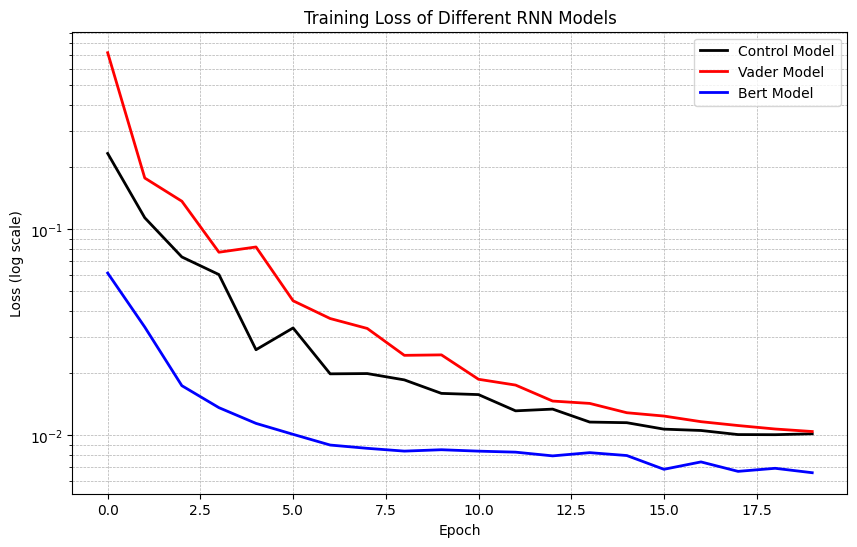

In [24]:
# Get the loss values from the history
control_loss = control_history.history['loss']
vader_loss = vader_history.history['loss']
bert_loss = bert_history.history['loss']

# Create the plot
plt.figure(figsize=(10, 6))

# Use thicker lines and adjust color for seismology effect
plt.semilogy(control_loss, label='Control Model', linewidth=2, color='black')
plt.semilogy(vader_loss, label='Vader Model', linewidth=2, color='red')
plt.semilogy(bert_loss, label='Bert Model', linewidth=2, color='blue')

# Customize ticks and grid for seismology appearance
plt.grid(True, which="both", linestyle='--', linewidth=0.5)  # Add grid lines
plt.gca().yaxis.set_minor_formatter(plt.NullFormatter())  # Remove minor ticks on y-axis

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss of Different RNN Models')

# Add legend
plt.legend()

# Show the plot
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


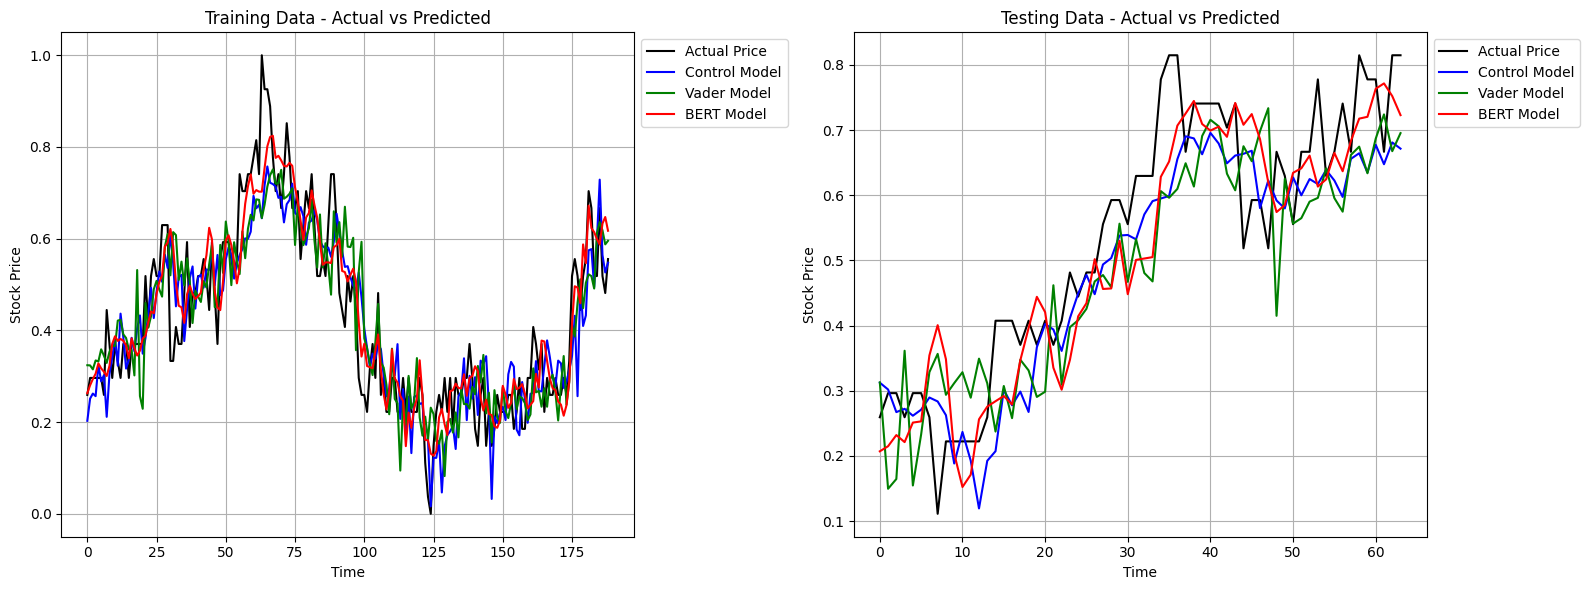

In [25]:
# Make predictions
def make_predictions(model=None, X=None, Y_true_scaled=None):
    """
    Make predictions using the input model.
    Returns both true and predicted values that are correctly scaled to the source data
    """
    Y_predictions_scaled = model.predict(X)
    Y_predictions_scaled = Y_predictions_scaled.reshape(-1)  # flatten if needed

    # Y_true_scaled is already in the scaled domain
    return Y_true_scaled, Y_predictions_scaled

# Training error
Y_train_true_control, Y_train_predictions_control = make_predictions(control_model, X_train_control, Y_train_control)
Y_train_true_vader, Y_train_predictions_vader = make_predictions(vader_model, X_train_vader, Y_train_vader)
Y_train_true_bert, Y_train_predictions_bert = make_predictions(bert_model, X_train_bert, Y_train_bert)

# Testing error
Y_test_true_control, Y_test_predictions_control = make_predictions(control_model, X_test_control, Y_test_control)
Y_test_true_vader, Y_test_predictions_vader = make_predictions(vader_model, X_test_vader, Y_test_vader)
Y_test_true_bert, Y_test_predictions_bert = make_predictions(bert_model, X_test_bert, Y_test_bert)

#model evauluation

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, mae

# Calculate metrics for each model
control_mse, control_rmse, control_mae = calculate_metrics(Y_test_true_control, Y_test_predictions_control)
vader_mse, vader_rmse, vader_mae = calculate_metrics(Y_test_true_vader, Y_test_predictions_vader)
bert_mse, bert_rmse, bert_mae = calculate_metrics(Y_test_true_bert, Y_test_predictions_bert)

# Create performance DataFrame
performance_df = pd.DataFrame({
    'Model': ['Control', 'Vader', 'BERT'],
    'MSE': [control_mse, vader_mse, bert_mse],
    'RMSE': [control_rmse, vader_rmse, bert_rmse],
    'MAE': [control_mae, vader_mae, bert_mae]
})

# Display the DataFrame
performance_df

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))  # Create subplots

# Training data plot (left)
ax1.plot(Y_train_control, label='Actual Price', color='black')
ax1.plot(Y_train_predictions_control, label='Control Model', color='blue')
ax1.plot(Y_train_predictions_vader, label='Vader Model', color='green')
ax1.plot(Y_train_predictions_bert, label='BERT Model', color='red')
ax1.set_title('Training Data - Actual vs Predicted')
ax1.set_xlabel('Time (Days)')
ax1.set_ylabel('Stock Price')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True)

# Testing data plot (right)
ax2.plot(Y_test_true_control, label='Actual Price', color='black')
ax2.plot(Y_test_predictions_control, label='Control Model', color='blue')
ax2.plot(Y_test_predictions_vader, label='Vader Model', color='green')
ax2.plot(Y_test_predictions_bert, label='BERT Model', color='red')
ax2.set_title('Testing Data - Actual vs Predicted')
ax2.set_xlabel('Time (Days)')
ax2.set_ylabel('Stock Price')
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [14]:
performance_df

,Model,MSE,RMSE,MAE
0,Control,0.000013,0.003561,0.003010
1,Vader,0.000012,0.003475,0.003020
2,BERT,0.000012,0.003480,0.003057
